Configuring unpretrained model: mBERT_Untrained


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=126375445023872 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=177,855,747 params_trainable=177,855,747


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,0.929600,0.796910,0.596667,0.586143,0.592991,0.596667,0.158067,47.420224
2,0.654600,0.747175,0.666667,0.664192,0.716355,0.666667,0.142956,42.886858
3,0.518200,0.694437,0.710000,0.707157,0.747437,0.710000,0.130598,39.179403
4,0.420000,0.495558,0.800000,0.801526,0.805235,0.800000,0.092485,27.745604


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=32.87s tok/s=0.0 ex/s=0.00 peak_mem=3.33GiB lr=7.98e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.23s tok/s=359657.2 ex/s=2809.82
[EVALUATION_PERFORMANCE] accuracy=0.5967 cost=$0.02 accuracy_per_$=31.40
[OPTIMIZER] epoch_start=1.0 global_step=150 wrapped=AcceleratedOptimizer base=AdamW lr=7.97872340425532e-06 id=126375445023872 hyperparams={'lr': 7.97872340425532e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 7.97872340425532e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[7.97872340425532e-06]
[PARAMS]   param

[EVALUATION_PERFORMANCE] tokens=81920 time=0.32s tok/s=258933.2 ex/s=2022.92
[EVALUATION_PERFORMANCE] accuracy=0.7867 cost=$0.10 accuracy_per_$=7.66

### BERT-BASE-MULTILINGUAL-CASED EVALUATION METRICS ###
{'epoch': 4.0,
 'eval_accuracy': 0.7866666666666666,
 'eval_f1_macro': 0.7866892216859878,
 'eval_loss': 0.5394362211227417,
 'eval_mse': 0.10293949811794707,
 'eval_precision_macro': 0.7867894632600515,
 'eval_recall_macro': 0.7866666666666666,
 'eval_runtime': 0.3896,
 'eval_samples_per_second': 769.944,
 'eval_sse': 30.881849435384122,
 'eval_steps_per_second': 12.832}


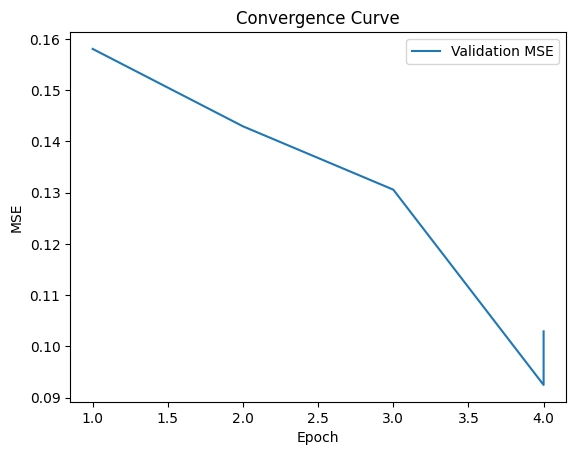

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mbertu_context = context.setup_pipeline(MBertUntrained, require_translation = False)
    mbertu_trainer = sentiment.train(mbertu_context)

